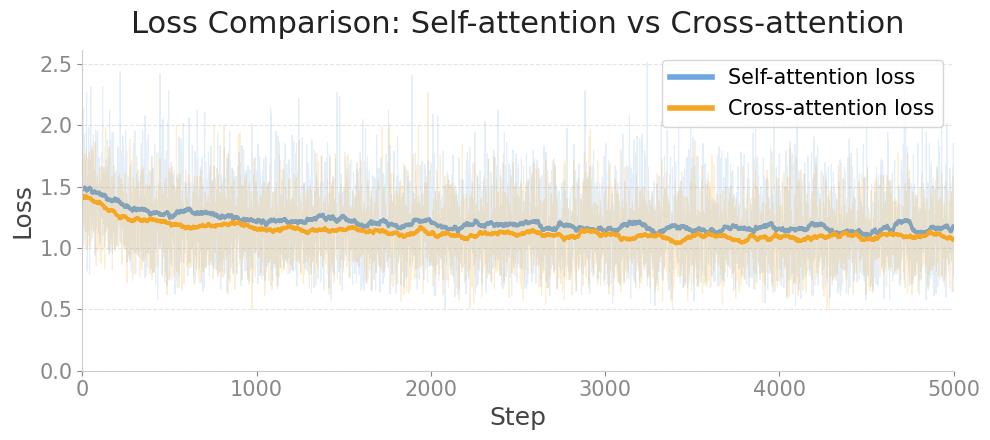

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import json

# --- Shared style ---
FIGSIZE        = (10, 4.5)
TITLE_FS       = 22
LABEL_FS       = 18
TICK_FS        = 15
ORIG_RAW       = "#4A90D9"   # blue — original loss
ORIG_SMOOTH    = "#4A90D9"
BATCH_RAW      = "#F5A623"   # orange — batched/packing loss (highlighted)
BATCH_SMOOTH   = "#F5A623"

# --- Load both datasets ---
with open('self_attention_batched_loss.json', 'r') as f:
    self_attn_values = json.load(f)

with open('cross_attention_batched_loss.json', 'r') as f:
    cross_attn_values = json.load(f)

def make_df(values):
    df = pd.DataFrame({'Loss': values})
    df['Step'] = df.index
    window = max(10, int(len(df) * 0.02))
    df['Smoothed'] = df['Loss'].rolling(window=window, min_periods=1, center=True).mean()
    return df

df_self_attn  = make_df(self_attn_values)
df_cross_attn = make_df(cross_attn_values)
n_steps  = min(len(df_self_attn), len(df_cross_attn))

# --- Plot ---
fig, ax = plt.subplots(figsize=FIGSIZE)

# Original loss — blue, subdued
ax.plot(df_self_attn['Step'][:n_steps],  df_self_attn['Loss'][:n_steps],     color=ORIG_RAW,    alpha=0.15, linewidth=0.8)
ax.plot(df_self_attn['Step'][:n_steps],  df_self_attn['Smoothed'][:n_steps], color=ORIG_SMOOTH, alpha=0.8,  linewidth=2.5)

# Batched/packing loss — orange, highlighted
ax.plot(df_cross_attn['Step'][:n_steps], df_cross_attn['Loss'][:n_steps],     color=BATCH_RAW,   alpha=0.2,  linewidth=0.8)
ax.plot(df_cross_attn['Step'][:n_steps], df_cross_attn['Smoothed'][:n_steps], color=BATCH_SMOOTH,            linewidth=2.5)

# Style
ax.set_title('Loss Comparison: Self-attention vs Cross-attention', fontsize=TITLE_FS, pad=12)
ax.set_xlabel('Step', fontsize=LABEL_FS)
ax.set_ylabel('Loss', fontsize=LABEL_FS)
ax.tick_params(labelsize=TICK_FS, colors='#888888')
ax.set_xlim(0, n_steps - 1)
ax.set_ylim(bottom=0)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')
ax.xaxis.label.set_color('#444444')
ax.yaxis.label.set_color('#444444')
ax.title.set_color('#222222')

ax.grid(axis='y', linestyle='--', alpha=0.5, color='#cccccc')

legend_handles = [
    Line2D([0], [0], color=ORIG_SMOOTH,  linewidth=4, alpha=0.8, label='Self-attention loss'),
    Line2D([0], [0], color=BATCH_SMOOTH, linewidth=4,            label='Cross-attention loss'),
]
ax.legend(handles=legend_handles, fontsize=TICK_FS, framealpha=0.8,
          edgecolor='#cccccc', loc='upper right')

plt.tight_layout()
plt.savefig('loss_comparison_attn_vlms.png', dpi=300, bbox_inches='tight')
plt.show()

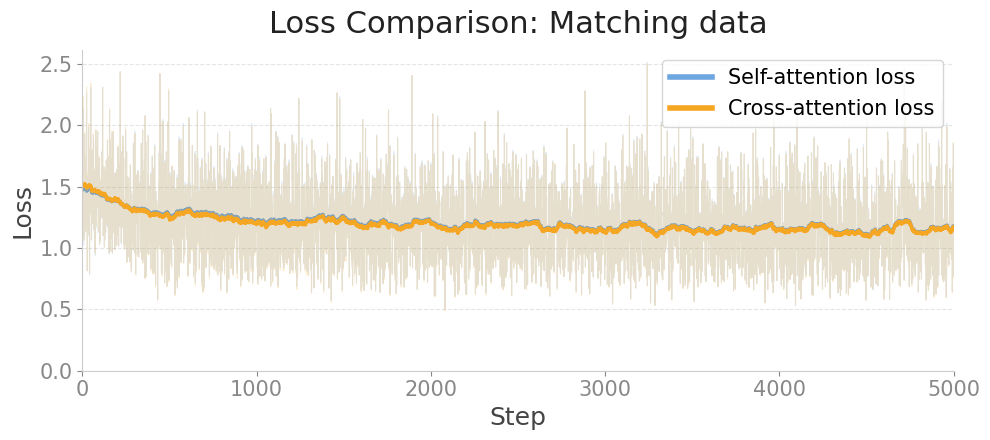

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import json

# --- Shared style ---
FIGSIZE        = (10, 4.5)
TITLE_FS       = 22
LABEL_FS       = 18
TICK_FS        = 15
ORIG_RAW       = "#4A90D9"   # blue — original loss
ORIG_SMOOTH    = "#4A90D9"
BATCH_RAW      = "#F5A623"   # orange — batched/packing loss (highlighted)
BATCH_SMOOTH   = "#F5A623"

# --- Load both datasets ---
with open('self_attention_batched_loss.json', 'r') as f:
    self_attn_values = json.load(f)

with open('chapter_6_batched_loss_right_padded_256_image_tokens.json', 'r') as f:
    cross_attn_values = json.load(f)

def make_df(values):
    df = pd.DataFrame({'Loss': values})
    df['Step'] = df.index
    window = max(10, int(len(df) * 0.02))
    df['Smoothed'] = df['Loss'].rolling(window=window, min_periods=1, center=True).mean()
    return df

df_self_attn  = make_df(self_attn_values)
df_cross_attn = make_df(cross_attn_values)
n_steps  = min(len(df_self_attn), len(df_cross_attn))

# --- Plot ---
fig, ax = plt.subplots(figsize=FIGSIZE)

# Original loss — blue, subdued
ax.plot(df_self_attn['Step'][:n_steps],  df_self_attn['Loss'][:n_steps],     color=ORIG_RAW,    alpha=0.15, linewidth=0.8)
ax.plot(df_self_attn['Step'][:n_steps],  df_self_attn['Smoothed'][:n_steps], color=ORIG_SMOOTH, alpha=0.8,  linewidth=2.5)

# Batched/packing loss — orange, highlighted
ax.plot(df_cross_attn['Step'][:n_steps], df_cross_attn['Loss'][:n_steps],     color=BATCH_RAW,   alpha=0.2,  linewidth=0.8)
ax.plot(df_cross_attn['Step'][:n_steps], df_cross_attn['Smoothed'][:n_steps], color=BATCH_SMOOTH,            linewidth=2.5)

# Style
ax.set_title('Loss Comparison: Matching data', fontsize=TITLE_FS, pad=12)
ax.set_xlabel('Step', fontsize=LABEL_FS)
ax.set_ylabel('Loss', fontsize=LABEL_FS)
ax.tick_params(labelsize=TICK_FS, colors='#888888')
ax.set_xlim(0, n_steps - 1)
ax.set_ylim(bottom=0)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')
ax.xaxis.label.set_color('#444444')
ax.yaxis.label.set_color('#444444')
ax.title.set_color('#222222')

ax.grid(axis='y', linestyle='--', alpha=0.5, color='#cccccc')

legend_handles = [
    Line2D([0], [0], color=ORIG_SMOOTH,  linewidth=4, alpha=0.8, label='Self-attention loss'),
    Line2D([0], [0], color=BATCH_SMOOTH, linewidth=4,            label='Cross-attention loss'),
]
ax.legend(handles=legend_handles, fontsize=TICK_FS, framealpha=0.8,
          edgecolor='#cccccc', loc='upper right')

plt.tight_layout()
plt.savefig('loss_comparison_attn_vlms_same_tokens.png', dpi=300, bbox_inches='tight')
plt.show()

In [5]:
df_cross_attn

,Loss,Step,Smoothed
0,3.3906,0,1.802730
1,2.6562,1,1.796182
2,2.2344,2,1.794392
3,2.7500,3,1.783532
4,1.8906,4,1.776691
...,...,...,...
4996,1.6875,4996,1.179687
4997,1.1484,4997,1.185691
4998,0.8555,4998,1.187277
4999,1.8750,4999,1.187723
